# 02 · Torneio de modelos

Quatro famílias disputam, com o **mesmo** Pipeline de preparo e a **mesma** validação temporal:

| Modelo | Ideia em uma frase |
|---|---|
| Regressão logística | soma ponderada das variáveis; simples, estável e fácil de explicar |
| Random forest | média de centenas de árvores de decisão independentes |
| XGBoost / LightGBM | árvores em sequência, cada uma corrigindo os erros da anterior (*boosting*) |

**Nota de cada configuração:** AUC médio de J1 (treina 2022 → testa 2023) e J2 (treina 2022–23 → testa 2024).

**Regra do campeão:** só vale trocar por algo mais complexo se ganhar pelo menos **0,005** de AUC médio.
Com ~240 inadimplentes em 2024, diferenças menores que isso são ruído.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from autocred import dados, modelos
from autocred.avaliacao import (
    LIMIAR_COMPLEXIDADE,
    avaliar_temporal,
    bootstrap_auc,
    bootstrap_diferenca_auc,
    escolher_campeao,
)

A = dados.carregar_base("A")
anos = dados.ano(A)
y = A[dados.ALVO].to_numpy()
X = {conjunto: A[dados.colunas_entrada(conjunto)] for conjunto in dados.CONJUNTOS}
dados.PASTA_SAIDAS.mkdir(exist_ok=True)


def rodar(descricao, conjunto="portatil"):
    return avaliar_temporal(lambda: modelos.construir_modelo(descricao, conjunto), X[conjunto], y, anos)

## 1. Busca: 25 configurações por família

Cada família tem "botões" (hiperparâmetros): profundidade das árvores, velocidade de aprendizado etc.
Sorteamos 25 combinações por família e medimos todas do mesmo jeito. Leva alguns minutos.

In [2]:
registros = []
for tipo in modelos.TIPOS:
    for i, params in enumerate(modelos.amostrar_configs(tipo)):
        descricao = {"tipo": tipo, "params": params, "monotonico": False}
        metricas, _ = rodar(descricao)
        registros.append({"candidato": tipo, "config": i, "descricao": descricao, **metricas})
    print(f"{tipo}: pronto")

logistica: pronto


random_forest: pronto


xgboost: pronto


lightgbm: pronto


## 2. Variante monotônica do melhor boosting

Forçamos o bom senso de crédito: mais restrições, mais consultas, LTV ou comprometimento maiores **nunca**
baixam o risco; score de bureau, renda e tempo de emprego maiores **nunca** aumentam. Isso deixa o modelo
mais fácil de defender e mais estável para perfis que ele nunca viu (Base C).

In [3]:
torneio = pd.DataFrame(registros)
melhor_por_tipo = torneio.loc[torneio.groupby("candidato")["auc_medio"].idxmax()]
boosting = melhor_por_tipo[melhor_por_tipo["candidato"].isin(["xgboost", "lightgbm"])]
tipo_mono = boosting.sort_values("auc_medio").iloc[-1]["candidato"]
for i, params in enumerate(modelos.amostrar_configs(tipo_mono)):
    descricao = {"tipo": tipo_mono, "params": params, "monotonico": True}
    metricas, _ = rodar(descricao)
    registros.append({"candidato": f"{tipo_mono}_monotonico", "config": i, "descricao": descricao, **metricas})
torneio = pd.DataFrame(registros)
torneio.assign(descricao=torneio["descricao"].map(json.dumps)).to_csv(
    dados.PASTA_SAIDAS / "torneio_resultados.csv", index=False
)
print(f"Variante monotônica: {tipo_mono}")

Variante monotônica: lightgbm


## 3. Melhor configuração de cada candidato + ensemble dos dois primeiros

,candidato,complexidade,auc_J1,auc_J2,auc_medio,ks_J1,ks_J2
5,ensemble,3,0.728680,0.747732,0.738206,0.372433,0.380788
0,lightgbm_monotonico,1,0.723885,0.749823,0.736854,0.361307,0.403803
1,lightgbm,2,0.727460,0.742056,0.734758,0.364438,0.373286
2,xgboost,2,0.720648,0.742423,0.731535,0.360973,0.385622
3,random_forest,2,0.709312,0.738106,0.723709,0.332396,0.382084
4,logistica,0,0.673691,0.659348,0.666520,0.287860,0.259839


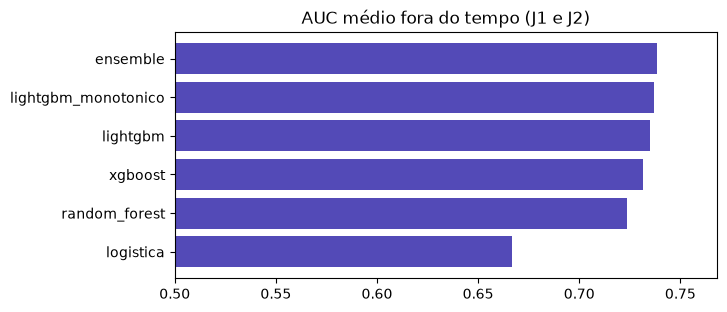

In [4]:
melhores = torneio.loc[torneio.groupby("candidato")["auc_medio"].idxmax()].sort_values("auc_medio", ascending=False)
desc_ensemble = {"tipo": "ensemble", "componentes": list(melhores["descricao"].iloc[:2])}
metricas_ensemble, _ = rodar(desc_ensemble)
candidatos = pd.concat(
    [melhores, pd.DataFrame([{"candidato": "ensemble", "config": -1, "descricao": desc_ensemble, **metricas_ensemble}])],
    ignore_index=True,
)
candidatos["complexidade"] = candidatos["descricao"].map(modelos.complexidade)
colunas = ["candidato", "complexidade", "auc_J1", "auc_J2", "auc_medio", "ks_J1", "ks_J2"]
display(candidatos[colunas].sort_values("auc_medio", ascending=False))

ordem = candidatos.sort_values("auc_medio")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(ordem["candidato"], ordem["auc_medio"], color="#534AB7")
ax.set_xlim(0.5, ordem["auc_medio"].max() + 0.03)
ax.set_title("AUC médio fora do tempo (J1 e J2)")
plt.show()

## 4. Campeão pela regra de complexidade

In [5]:
campeao = escolher_campeao(candidatos)
y_2024 = y[anos == 2024]
_, prev_campeao = rodar(campeao["descricao"])
_, prev_logistica = rodar(melhores.set_index("candidato").loc["logistica", "descricao"])
ic = bootstrap_auc(y_2024, prev_campeao["J2"])
dif = bootstrap_diferenca_auc(y_2024, prev_campeao["J2"], prev_logistica["J2"])
print(f"Campeão: {campeao['candidato']} | AUC médio {campeao['auc_medio']:.4f}")
print(f"AUC em 2024: {campeao['auc_J2']:.4f} (IC 95%: {ic[0]:.4f} a {ic[1]:.4f})")
print(f"Diferença para a logística em 2024: {dif[0]:+.4f} (IC 95%: {dif[1]:+.4f} a {dif[2]:+.4f})")

Campeão: lightgbm_monotonico | AUC médio 0.7369
AUC em 2024: 0.7498 (IC 95%: 0.7164 a 0.7837)
Diferença para a logística em 2024: +0.0899 (IC 95%: +0.0635 a +0.1175)


## 5. A taxa antiga ajuda?

`taxa_juros_am` existe na concessão, mas reflete o preço **antigo**. Na Base C a taxa será decidida pela
política nova, e taxa alta atrai quem não tem alternativa (seleção adversa). Só usamos a taxa na submissão
da Base B se ela ganhar pelo menos 0,005 de AUC médio. A Base C sempre usa o modelo **portátil**.

In [6]:
metricas_completo, _ = rodar(campeao["descricao"], "completo")
ganho_taxa = metricas_completo["auc_medio"] - campeao["auc_medio"]
conjunto_b = "completo" if ganho_taxa >= LIMIAR_COMPLEXIDADE else "portatil"
print(f"Ganho com a taxa: {ganho_taxa:+.4f} -> Base B usa o conjunto {conjunto_b}")

Ganho com a taxa: -0.0018 -> Base B usa o conjunto portatil


In [7]:
resultado = {
    "descricao": campeao["descricao"],
    "candidato": campeao["candidato"],
    "complexidade": int(campeao["complexidade"]),
    **{k: float(campeao[k]) for k in ["auc_J1", "auc_J2", "auc_medio", "ks_J1", "ks_J2"]},
    "ic95_auc_J2": [ic[0], ic[1]],
    "dif_vs_logistica_J2": list(dif),
    "auc_medio_completo": float(metricas_completo["auc_medio"]),
    "ganho_taxa": float(ganho_taxa),
    "conjunto_b": conjunto_b,
    "candidatos": candidatos[colunas].to_dict("records"),
}
with open(dados.PASTA_SAIDAS / "campeao.json", "w", encoding="utf-8") as arquivo:
    json.dump(resultado, arquivo, ensure_ascii=False, indent=2)
print(json.dumps({k: resultado[k] for k in ["candidato", "auc_medio", "conjunto_b"]}, ensure_ascii=False))

{"candidato": "lightgbm_monotonico", "auc_medio": 0.7368538461564089, "conjunto_b": "portatil"}
